# PDF Parsing Playground

This notebook lets you run each step interactively:

- confirm the environment
- inspect the local sample PDF
- parse it locally with `PyPDF2`
- display parsed text metadata
- save extracted text
- include a Databricks `ai_parse_document` template for later use

If VS Code asks, select the `Python 3` kernel for this notebook.

In [6]:
# Section 1: Environment and Setup
import sys
import os
import random

print("Python version:", sys.version)
print("Current working directory:", os.getcwd())
print("Sample PDF folder exists:", os.path.exists(os.path.join(os.getcwd(), 'sample-pdf')))
print("Python executable:", sys.executable)

random.seed(42)

try:
    import numpy as np
    import pandas as pd
except ImportError as err:
    print("Missing package:", err)
    print("Install dependencies with:")
    print(f"  {sys.executable} -m pip install numpy pandas PyPDF2")
else:
    np.random.seed(42)
    print("numpy version:", np.__version__)
    print("pandas version:", pd.__version__)


Python version: 3.12.12 (main, Oct  9 2025, 11:07:00) [Clang 17.0.0 (clang-1700.6.3.2)]
Current working directory: /Users/home.asthana/02-madhu/git-tt/ai/dbx-playground
Sample PDF folder exists: True
Python executable: /Users/home.asthana/02-madhu/git-tt/ai/.venv/bin/python
numpy version: 2.4.6
pandas version: 3.0.3


In [7]:
# Install dependencies for this notebook if they are missing
# Run this cell once before the rest if you see ImportError messages.
%pip install numpy pandas PyPDF2 matplotlib pytest


Note: you may need to restart the kernel to use updated packages.


In [8]:
# Section 2: Imports and Version Checks
import importlib

libraries = ['PyPDF2', 'numpy', 'pandas', 'matplotlib', 'pytest']
for lib in libraries:
    try:
        module = importlib.import_module(lib)
        version = getattr(module, '__version__', 'unknown')
        print(f"{lib}: installed, version {version}")
    except ImportError:
        print(f"{lib}: NOT installed")

# quick check for plotting support and display
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(4, 2))
    plt.title('Plot check')
    plt.plot([0, 1], [0, 1])
    plt.close()
    print('matplotlib plotting available')
except Exception as err:
    print('matplotlib import or plot failed:', err)


PyPDF2: installed, version 3.0.1
numpy: installed, version 2.4.6
pandas: installed, version 3.0.3
matplotlib: installed, version 3.10.9
pytest: installed, version 9.0.3
matplotlib plotting available


In [9]:
# Section 3: Define Helper Functions
from pathlib import Path
from typing import List

PDF_PATH = Path('sample-pdf/TIL 1603-R2 - R0 EROSION AND WATER INGESTION RECOMMENDATIONS.pdf')
OUTPUT_TEXT_PATH = Path('sample-pdf/extracted_text.txt')


def verify_pdf_path(path: Path) -> bool:
    """Return True if the PDF exists and is readable."""
    return path.exists() and path.is_file()


def load_pdf_text(path: Path, max_pages: int = 3) -> List[str]:
    """Extract text from the first pages of a PDF using PyPDF2."""
    from PyPDF2 import PdfReader
    reader = PdfReader(path)
    pages = []
    for i, page in enumerate(reader.pages[:max_pages]):
        pages.append(page.extract_text() or '')
    return pages


def save_text(path: Path, text: str) -> None:
    """Save text to a file and verify it was written."""
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding='utf-8')
    assert path.exists(), f'Failed to save file: {path}'


# Example calls
print('PDF path:', PDF_PATH)
print('Exists:', verify_pdf_path(PDF_PATH))


PDF path: sample-pdf/TIL 1603-R2 - R0 EROSION AND WATER INGESTION RECOMMENDATIONS.pdf
Exists: True


In [10]:
# Section 4: Load Sample PDF and Inspect
if not verify_pdf_path(PDF_PATH):
    raise FileNotFoundError(f"Sample PDF not found: {PDF_PATH}")

page_texts = load_pdf_text(PDF_PATH, max_pages=4)
print(f"Loaded {len(page_texts)} pages of text preview.")
for idx, page in enumerate(page_texts, start=1):
    print('\n' + '=' * 60)
    print(f'Page {idx} preview:')
    print('-' * 60)
    print(page[:800].strip())


Loaded 4 pages of text preview.

Page 1 preview:
------------------------------------------------------------
GE Power
POWER SER VICES ENGINEERING TIL 1603-R2
PRODUCT SER VICE 12 FEBRUAR Y 2019
Compliance Category -  C
Timing Code -  5
TECHNICAL INFORMA TION LETTER
R0 EROSION AND W ATER INGESTION RECOMMENDA TIONS
APPLICA TION
All F-class gas turbines excluding 6F.01, 7F.04-200 and 7F.05.
PURPOSE
To advise operators of the inspection and maintenance considerations necessary to mitigate R0 erosion effects, and
to inform them of a new online water wash (OnWW) system that reduces the rate of erosion in the principal area of
concern.  Failure to properly monitor or repair R0 erosion could result in cracking of the R0 blades and risks of
compressor damage.
REASON FOR REVISION
The reason for this revision is to improve the clarity of the recommendations regarding online water wash frequency and mold
insp

Page 2 preview:
------------------------------------------------------------
BACKGROUND 

In [11]:
# Section 5: Core Computation / Example
import pandas as pd

pdf_df = pd.DataFrame({
    'page_number': list(range(1, len(page_texts) + 1)),
    'text': page_texts,
    'char_count': [len(text) for text in page_texts],
    'word_count': [len(text.split()) for text in page_texts],
})

print('DataFrame shape:', pdf_df.shape)
pdf_df.head(10)


DataFrame shape: (4, 4)


,page_number,text,char_count,word_count
0,1,GE Power\nPOWER SER VICES ENGINEERING TIL 1603...,3154,491
1,2,BACKGROUND DISCUSSION\nAs the forward-most rot...,2967,446
2,3,\n \nFigure 3: Erosion Mold Inspections (n...,3848,582
3,4,For current F-class units operating with the o...,5927,903


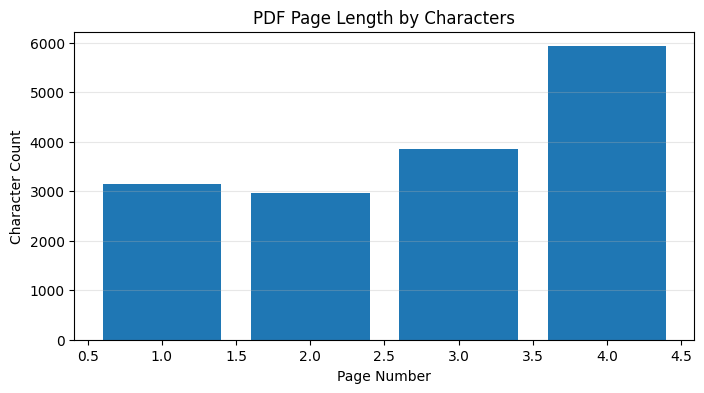

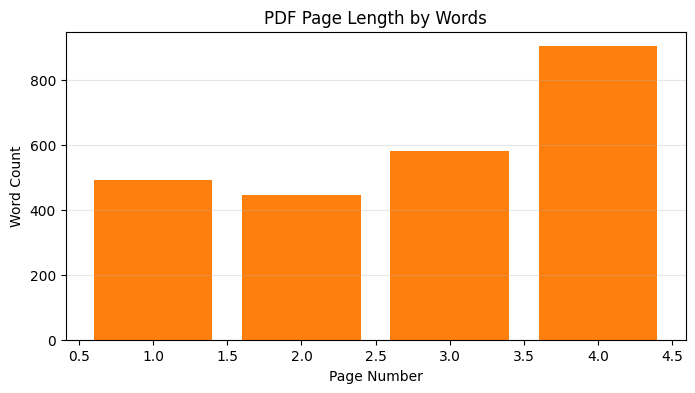

In [12]:
# Section 6: Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(pdf_df['page_number'], pdf_df['char_count'], color='tab:blue')
plt.xlabel('Page Number')
plt.ylabel('Character Count')
plt.title('PDF Page Length by Characters')
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(pdf_df['page_number'], pdf_df['word_count'], color='tab:orange')
plt.xlabel('Page Number')
plt.ylabel('Word Count')
plt.title('PDF Page Length by Words')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [13]:
# Section 7: Unit Tests (pytest) and Output Pane

assert verify_pdf_path(PDF_PATH), f"PDF does not exist: {PDF_PATH}"
assert len(page_texts) > 0, "No page text was extracted from the PDF"
assert all(isinstance(text, str) for text in page_texts), "Extracted page text must be strings"
print('Inline notebook assertions passed.')

print('Optional pytest command:')
print('!pytest -q dbx-playground/test_parse_pdf_tests.py')


Inline notebook assertions passed.
Optional pytest command:
!pytest -q dbx-playground/test_parse_pdf_tests.py


In [14]:
# Section 8: Save Results and Artifacts
full_text = '\n\n'.join(page_texts)
save_text(OUTPUT_TEXT_PATH, full_text)

print('Saved extracted text to:', OUTPUT_TEXT_PATH)
print('Saved file exists:', OUTPUT_TEXT_PATH.exists())
print('Saved file size:', OUTPUT_TEXT_PATH.stat().st_size if OUTPUT_TEXT_PATH.exists() else 'N/A')


Saved extracted text to: sample-pdf/extracted_text.txt
Saved file exists: True
Saved file size: 15922


In [ ]:
# Section 8b: Databricks Parsing Template

# Use this code in a Databricks notebook once the PDF is accessible in DBFS or a volume.
# Replace '<pdf-directory-path>' and '<output-path>' with actual paths in your workspace.

from pyspark.sql.functions import expr

docs_df = spark.read.format('binaryFile').load('<pdf-directory-path>')
parsed_df = docs_df.withColumn(
    'parsed_content',
    expr(
        "ai_parse_document(content, map('version', '2.0', 'imageOutputPath', '<output-path>/parsed_images/'))"
    )
)
parsed_df = parsed_df.drop('content')
display(parsed_df)

# Inspect nested fields like:
#  parsed_content:document:pages
#  parsed_content:document:elements
#  parsed_content:metadata


In [ ]:
# Section 9: Run All Cells and Inspect Output
print('This notebook is ready to run end-to-end.')
print('Use VS Code: Kernel -> Restart Kernel and Run All Cells')
print('Watch the Output pane for logs, cell results, and any errors.')
print('\nChecklist:')
print('1. Section 1: verify environment and installed packages')
print('2. Section 2: confirm imports and library versions')
print('3. Section 3: define helper functions and sample PDF path')
print('4. Section 4: load PDF pages and preview extracted text')
print('5. Section 5: convert extracted content into a DataFrame')
print('6. Section 6: visualize page lengths')
print('7. Section 7: run inline assertions and optional pytest command')
print('8. Section 8: save extracted text to disk')
print('9. Confirm saved file path exists and is populated.')
